# Intelligent Customer Complaint Resolution & Escalation Engine

In [87]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
import operator


In [88]:
load_dotenv()

True

In [89]:
model = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0.7
)


In [90]:
class ClassificationtSchema(BaseModel):
    category:Literal[ "Billing", "Technical", "Account_Access", "Abuse_or_Threat" ,"General_Inquiry"]=Field(description='classification of the complaint')
    
    

In [91]:
class priorityDecisionSchema(BaseModel):
    escalation_path:Literal['Assign_to_human_review','Mark_compliance_flag','Add_legal_audit_note','Generate_holding_response']=Field(description='Escalation path conditions')
    high_priority_path:Literal['Generate_refund_recommendation','Draft_apology','Create_fast-track_response']=Field(description='high priority tasked path conditions')
    standard_path:Literal['Generate_troubleshooting_steps','Provide_resolution_estimate','Log_ticket_creation']=Field(description='standard response path conditions')
    auto_response_path:Literal['Generate_FAQ-based_response','Close_case_automatically']=Field(description='auto response path')
    selected_path:Literal['escalation_path','high_priority_path','standard_path','auto_response_path']=Field(description='single route to execute for this complaint')
    

In [92]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "neutral","negative"] = Field(description='Sentiment of the review')

In [93]:
structured_model = model.with_structured_output(ClassificationtSchema)
# structured_model_1=model.with_structured_output(SentimentSchema)
structured_model_2=model.with_structured_output(priorityDecisionSchema)

In [94]:
prompt = 'what is the category of the following complaint-I want to know how to proeed with this payment'
structured_model.invoke(prompt).category

'Billing'

In [95]:
class ReviewState(TypedDict, total=False):
    complaint_text:str 
    category:Literal[ "Billing", "Technical", "Account_Access", "Abuse_or_Threat" ,"General_Inquiry"]
    sentiment_urgency:str
    priority_level:dict
    escalation_path: str
    high_priority_path: str 
    standard_path : str
    auto_response_path:str 
    selected_path:Literal['escalation_path','high_priority_path','standard_path','auto_response_path']
    final_response:str 
    audit_log:Annotated[list[str],operator.add]
    

In [96]:
def define_category(state:ReviewState):
    prompt = f'For the following complaint find out the category \n {state["complaint_text"]}'
    category = structured_model.invoke(prompt).category

    return {'category': category, 'audit_log': [f"Category identified: {category}"]}

In [97]:
def review_category_sentiment_urgency(state:ReviewState):
    
    prompt = f'Review this complaint in category {state["category"]}. Provide sentiment, urgency, threat indicator, legal risk indicator, and emotional intensity.\n{state["complaint_text"]}'
    sentiment_urgency = model.invoke(prompt).content
    
    return {'sentiment_urgency':sentiment_urgency, 'audit_log': ["Sentiment and urgency assessed"]}

In [98]:
def Priority_decision(state:ReviewState):
    prompt = f"""Diagnose this user complaint:\n\n{state['complaint_text']}\n\nReturn values for escalation_path, high_priority_path, standard_path, auto_response_path, and selected_path where selected_path must be one of: escalation_path, high_priority_path, standard_path, auto_response_path."""
    response = structured_model_2.invoke(prompt)
    decision = response.model_dump()
    selected_path = decision['selected_path']

    return {'priority_level': decision, 'selected_path': selected_path, 'audit_log': [f"Priority route selected: {selected_path}"]}

    

In [99]:
def escalation_path(state:ReviewState):
    priority_level=state['priority_level']
    # escalation_path=state['escalation_path']
    prompt = f"""You are a support assistant.
The user had a '{priority_level['escalation_path']}' issue,  
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'escalation_path': response, 'audit_log': ["Escalation response drafted"]}

In [100]:
def high_priority_path(state:ReviewState):
    priority_level=state['priority_level']
    
    prompt = f"""You are a support assistant.
The user had a '{priority_level['high_priority_path']}' issue,  
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'high_priority_path': response, 'audit_log': ["High-priority response drafted"]}

In [101]:
def standard_path(state:ReviewState):
    priority_level=state['priority_level']
    
    prompt = f"""You are a support assistant.
The user had a '{priority_level['standard_path']}' issue,  
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'standard_path': response, 'audit_log': ["Standard response drafted"]}

In [102]:
def auto_response_path(state:ReviewState):
    priority_level=state['priority_level']
    
    prompt = f"""You are a support assistant.
The user had a '{priority_level['auto_response_path']}' issue,  
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'auto_response_path': response, 'audit_log': ["Auto-response drafted"]}

In [103]:
def aggregate_report(state:ReviewState):
    audit_log = state.get('audit_log', [])
    selected_path = state.get('selected_path', 'standard_path')
    resolution_message = state.get(selected_path, '')
    audit_text = "\n".join(audit_log)
    prompt=f"""Generate structured final output:\n1.Case ID\n2.Category\n3.Priority\n4.Escalation flag\n5.Resolution summary\n6.Final response message\n\nCategory: {state.get('category', '')}\nSentiment/Urgency: {state.get('sentiment_urgency', '')}\nSelected Path: {selected_path}\nDecision Details: {state.get('priority_level', {})}\nResolution Message: {resolution_message}\nAudit Log:\n{audit_text}\n"""
    response = model.invoke(prompt).content 
    
    return {'final_response':response, 'audit_log': ["Final report generated"]}

In [104]:
graph = StateGraph(ReviewState)

graph.add_node('define_category',define_category)
graph.add_node('review_category_sentiment_urgency', review_category_sentiment_urgency)
graph.add_node('Priority_decision', Priority_decision)
graph.add_node('escalation_path', escalation_path)
graph.add_node('high_priority_path',high_priority_path)
graph.add_node('standard_path',standard_path)
graph.add_node('auto_response_path',auto_response_path)
graph.add_node('aggregate_report',aggregate_report)

graph.add_edge(START, 'define_category')

graph.add_edge('define_category', 'review_category_sentiment_urgency')
graph.add_edge('review_category_sentiment_urgency','Priority_decision')
graph.add_conditional_edges('Priority_decision', lambda state: state['selected_path'])
 
graph.add_edge('escalation_path', 'aggregate_report')
graph.add_edge('high_priority_path', 'aggregate_report')
graph.add_edge('standard_path', 'aggregate_report')
graph.add_edge('auto_response_path', 'aggregate_report')
graph.add_edge('aggregate_report',END)

workflow = graph.compile()

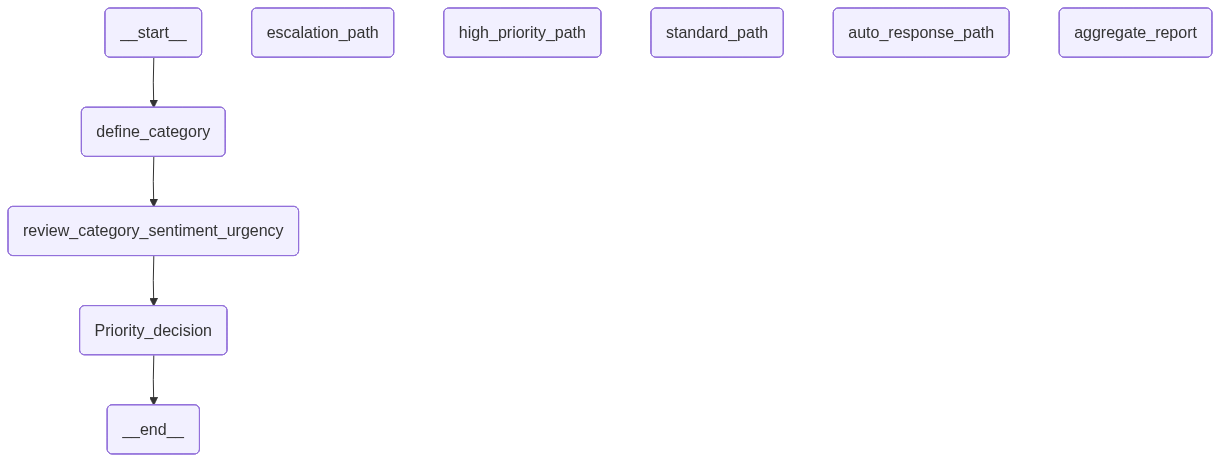

In [105]:
workflow

In [106]:
complaint="I was charged twice for my subscription and your support team is not responding. If this isn't fixed today, I will file a complaint."
initial_state={'complaint_text':complaint, 'audit_log': []}

In [107]:
workflow.invoke(initial_state)

{'complaint_text': "I was charged twice for my subscription and your support team is not responding. If this isn't fixed today, I will file a complaint.",
 'category': 'Billing',
 'sentiment_urgency': 'Here\'s the review of the complaint:\n\n**Sentiment:** Negative\nThe customer is unhappy with the billing issue and the lack of response from the support team.\n\n**Urgency:** High\nThe customer is requesting immediate action to rectify the issue, stating that if it\'s not fixed today, they will file a complaint.\n\n**Threat Indicator:** Medium-High\nThe customer explicitly states that they will file a complaint if the issue is not resolved today, which implies a threat of escalating the issue and possibly damaging the company\'s reputation.\n\n**Legal Risk Indicator:** Medium\nWhile the customer is threatening to file a complaint, they haven\'t explicitly mentioned any legal action or regulatory bodies. However, in the context of billing disputes, there is a risk of potential legal acti